# Day 12 of ML 30-Days Challenge

# Task

**Multiple Linear Regression**: Extend linear regression to multiple variables. Learn to identify and handle multicollinearity (high correlation between predictor variables) and perform basic feature selection to build a more robust model.

using all previous topics

In [23]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

###1. Create custom regression dataset with NaN values

In [24]:
np.random.seed(42)
X, y = make_regression(n_samples=200, n_features=4, noise=15.0)  # you can use to get dataset 😎
df = pd.DataFrame(X, columns=['feat1', 'feat2', 'feat3', 'feat4'])
df['target'] = y

for col in ['feat1', 'feat2']:
    df.loc[df.sample(frac=0.1, random_state=42).index, col] = np.nan # imputing random nan into feat1 and feat2

X = df.drop('target', axis=1)
y = df['target']

bins = pd.qcut(y, q=5, duplicates='drop', labels=False)

df.describe()

# I choose to impute values from simple imputer mean rather than droping (if droped you get better result)

,feat1,feat2,feat3,feat4,target
count,180.000000,180.000000,200.000000,200.000000,200.000000
mean,0.064584,-0.029147,-0.063867,-0.006107,1.265757
std,1.003319,1.047675,0.904081,0.972495,109.451095
min,-2.301921,-3.241267,-2.650970,-1.959670,-250.753449
25%,-0.580562,-0.710849,-0.704751,-0.683665,-75.306632
50%,0.053652,0.021472,-0.016005,-0.066986,-8.767020
75%,0.769235,0.624553,0.504450,0.617664,75.870567
max,2.720169,3.078881,2.314659,3.852731,393.131827


###2. Stratified split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=bins)

###3. Build pipeline: Impute & Scale

In [26]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

###4. Train linear regression model

In [27]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

###5. Predict on test set (predictions are in terms of scaled features)

In [28]:
y_pred = model.predict(X_test_scaled)

###6. Evaluate

In [29]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.2f}') # pretty good isn't it, more better if droped nan values

Mean Absolute Error: 14.75
R^2 Score: 0.96


###7. show Original vs predicted values

Just to be sure what we are truly getting with our mind😅

In [30]:
results = pd.DataFrame({
    'Original': y_test.values,
    'Predicted': y_pred
})
print(results.head())

     Original   Predicted
0   44.796741   37.881193
1  -92.661290  -92.701863
2 -184.651908 -180.649840
3  -61.667199  -41.602159
4  123.821352  123.857333


###8. (Optional) Visualization : just for visuals

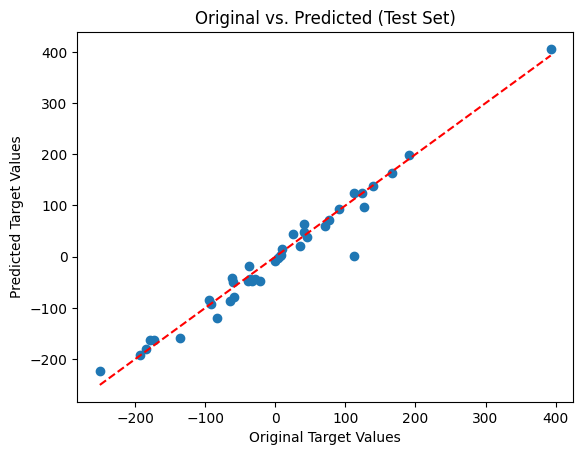

In [31]:
plt.scatter(y_test, y_pred)
plt.xlabel('Original Target Values')
plt.ylabel('Predicted Target Values')
plt.title('Original vs. Predicted (Test Set)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.show()